In [2]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from pathlib import Path

In [3]:
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
            'leaf_hydraulic_capacitance', 'psi50_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0',
            'jackson_root_beta',
            'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

vars_sel = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
            'leaf_hydraulic_capacitance', 'psi50_xylem', 'g0', 'k_soil_sat0', 'psi_soil_sat0',
            'jackson_root_beta', 'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0', 'jackson_root_beta']
df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
df_grp = df.groupby(['id'])[vars_all].mean()
dv = df_grp
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm = (dv - dv.mean()) / dv.std()

In [4]:
df = df_norm[vars_all]
tsne = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3)
x_tsne = tsne.fit_transform(df)

In [5]:
tsne.kl_divergence_

1.787517786026001

In [17]:
perplexity = np.arange(50,100, 5)
divergence = []

for i in perplexity:
    model = TSNE(n_components=2, init="pca", perplexity=i)
    reduced = model.fit_transform(df)
    divergence.append(model.kl_divergence_)

In [6]:
plt.plot(perplexity, divergence)

NameError: name 'perplexity' is not defined

In [20]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2,perplexity=150, random_state=42)
X_train_tsne = tsne.fit_transform(df)

tsne.kl_divergence_

1.706978678703308

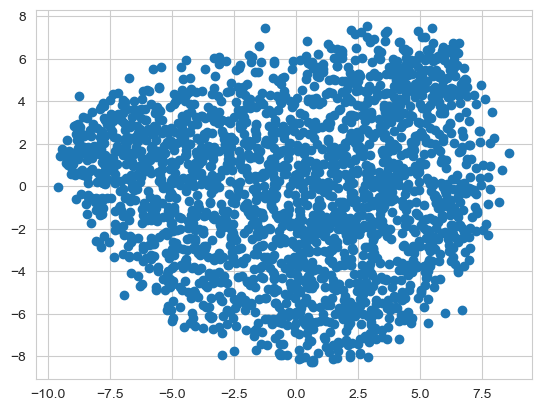

In [22]:
plt.scatter(x=X_train_tsne[:, 0], y=X_train_tsne[:, 1])


In [23]:
X_train_tsne

array([[-0.3545646 ,  0.8808347 ],
       [ 4.2146916 ,  3.8066998 ],
       [ 3.9506402 ,  4.722885  ],
       ...,
       [-5.846321  ,  0.63399184],
       [-6.3068867 ,  2.5763273 ],
       [-1.6512446 , -0.16480443]], dtype=float32)

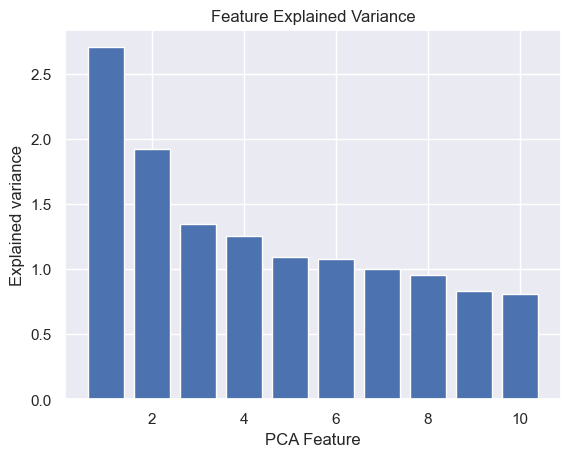

In [6]:
import matplotlib.pyplot as plt 
import seaborn as sns
sns.set()

# Bar plot of explained_variance
plt.bar(
    range(1,len(pca.explained_variance_)+1),
    pca.explained_variance_
    )


plt.xlabel('PCA Feature')
plt.ylabel('Explained variance')
plt.title('Feature Explained Variance')
plt.show()

In [7]:
loadings = pca_out.components_
num_pc = pca_out.n_features_in_
pc_list = ["PC"+str(i) for i in list(range(1, num_pc+1))]
loadings_df = pd.DataFrame.from_dict(dict(zip(pc_list, loadings)))


NameError: name 'pca_out' is not defined

In [8]:
pca_features = pca.fit_transform(df)

# Principal components correlation coefficients
loadings = pca.components_

# Number of features before PCA
n_features = pca.n_features_in_

# Feature names before PCA
feature_names = df.columns.values

# PC names
pc_list = [f'PC{i}' for i in list(range(1, n_features + 1))]

# Match PC names to loadings
pc_loadings = dict(zip(pc_list, loadings))

# Matrix of corr coefs between feature names and PCs
loadings_df = pd.DataFrame.from_dict(pc_loadings)
loadings_df['feature_names'] = feature_names
loadings_df = loadings_df.set_index('feature_names')

In [9]:
pca.explained_variance_ratio_

array([0.19310848, 0.137426  , 0.09631979, 0.0893264 , 0.07809992,
       0.07700245, 0.07145835, 0.06792864, 0.05944461, 0.05782835])

In [10]:
# Get the loadings of x and y axes
xs = loadings[0]
ys = loadings[1]


# Create DataFrame from PCA
pca_df = pd.DataFrame(
    data=pca_features, 
    columns=[f"PC{i}" for i in range(1,10 + 1)])


# Scale PCS into a DataFrame
pca_df_scaled = pca_df.copy()

scaler_df = pca_df[['PC1', 'PC2']]
scaler = 1 / (scaler_df.max() - scaler_df.min())

for index in scaler.index:
    pca_df_scaled[index] *= scaler[index]


<Figure size 800x800 with 0 Axes>

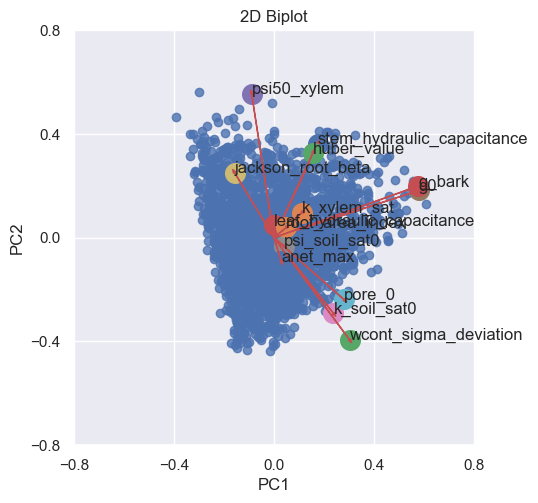

In [11]:
# Plot the loadings on a Scatter plot
xs = loadings[0]
ys = loadings[1]
fig = plt.figure(figsize=(8, 8))

sns.lmplot(
    x='PC1', 
    y='PC2', 
    data=pca_df_scaled, 
    fit_reg=False, 
    )

for i, varnames in enumerate(feature_names):
    plt.scatter(xs[i], ys[i], s=200)
    plt.arrow(
        0, 0, # coordinates of arrow base
        xs[i], # length of the arrow along x
        ys[i], # length of the arrow along y
        color='r', 
        head_width=0.01
        )
    plt.text(xs[i], ys[i], varnames)

xticks = np.linspace(-0.8, 0.8, num=5)
yticks = np.linspace(-0.8, 0.8, num=5)
plt.xticks(xticks)
plt.yticks(yticks)
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.title('2D Biplot')
plt.show()

In [86]:
loadings[1].size

17

In [85]:
loadings[0].size

17

In [91]:
pca_out.explained_variance_ratio_[0]

0.14912362335939586

In [155]:
pca.explained_variance_

array([2.48821277, 1.47125163, 1.35009754, 1.16535668, 1.13564537,
       1.09009217, 1.02276338, 0.98020802, 0.94251096, 0.90885076])

In [158]:
np.cumsum(pca.explained_variance_ratio_) 

array([0.17772948, 0.28281889, 0.37925442, 0.46249419, 0.54361171,
       0.62147544, 0.69452997, 0.76454483, 0.83186704, 0.89678495])

In [81]:
df.columns.values

array(['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance',
       'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance',
       'psi50_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0',
       'jackson_root_beta', 'pore_0', 'anet_max', 'root_area_index',
       'wcont_sigma_deviation', 'g_bark'], dtype=object)

In [62]:
df.columns.values

array(['Unnamed: 0', 'index', 'id', 'dts', 'dts_input', 'verbose',
       'max_psi_leaf_change_per_hour', 'minimum_psi_leaf_multiplier',
       'conductivity_fraction_type', 'anet_max', 'sw_rad_max',
       'root_area_index', 'canopy_height', 'stem_flow_type',
       'n_stem_segments', 'eta_LS', 'stem_hydraulic_capacitance',
       'k_xylem_sat', 'huber_value', 'psi50_xylem', 'psi88_xylem',
       'sustain_xylem_damage', 'permanent_xylem_fraction_threshold',
       'leaf_hydraulic_capacitance', 'leaf_area_index',
       'psi_leaf_50_close', 'd_50_close', 'g0', 'g1', 'g_bark',
       'soil_depths', 'jackson_root_beta', 'soil_water_model_type',
       'k_soil_sats', 'psi_soil_sats', 'sand_fracs', 'clay_fracs',
       'organic_matter_fracs', 'theta_r', 'theta_s', 'camp_b',
       'pore_size_ind', 'tree_density', 'sigma_log_likelyhood',
       'soil_profile_index', 'wcont_sigma_deviation', 'solver_precision',
       'psi_soil_sat0', 'k_soil_sat0', 'theta_s0', 'theta_r0', 'pore_0',
       '